In [1]:
pip install catboost

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np


groups = ["NCD", 'AI', 'AS(NA)', 'BL',
         'NAC', 'AS(NAC)', 'CS', 'AT', 'NA','ADL', 'NAD']

columns = [f"{group}_{t}" for group in groups for t in range(7)]
columns.append("target")

df = pd.read_csv(
    "Twitter.data",
    header=None,
    names=columns
)

print(df.shape)
#df.head(20)

df["target_log"] = np.log1p(df["target"])

(583250, 78)


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from catboost import CatBoostRegressor

# 1. Ознаки і target
X = df.drop(columns=["target", "target_log"])
y = df["target_log"]

# 2. Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. CatBoost
cat_model = CatBoostRegressor(
    iterations=300,
    depth=8,
    learning_rate=0.1,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    verbose=100
)

# 4. Навчання
cat_model.fit(X_train, y_train)

# 5. Прогноз
y_pred_log = cat_model.predict(X_test)

# 6. Метрики
mae_log = mean_absolute_error(y_test, y_pred_log)
rmse_log = mean_squared_error(y_test, y_pred_log) ** 0.5
r2_log = r2_score(y_test, y_pred_log)

print("CatBoost Regression on log(target)")
print(f"MAE  (log scale): {mae_log:.4f}")
print(f"RMSE (log scale): {rmse_log:.4f}")
print(f"R²   (log scale): {r2_log:.4f}")

0:	learn: 1.8286272	total: 215ms	remaining: 1m 4s
100:	learn: 0.4727623	total: 5.41s	remaining: 10.7s
200:	learn: 0.4674022	total: 10.8s	remaining: 5.33s
299:	learn: 0.4636105	total: 16.6s	remaining: 0us
CatBoost Regression on log(target)
MAE  (log scale): 0.3362
RMSE (log scale): 0.4693
R²   (log scale): 0.9455


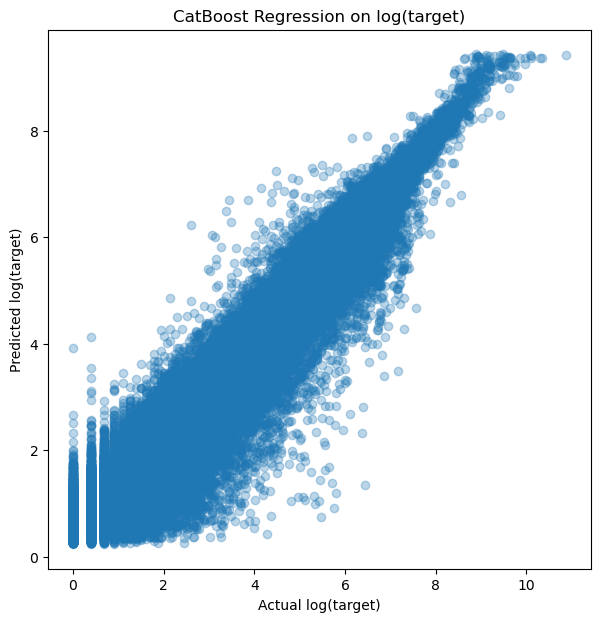

In [4]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_log, alpha=0.3)
plt.xlabel("Actual log(target)")
plt.ylabel("Predicted log(target)")
plt.title("CatBoost Regression on log(target)")
plt.show()